In [1]:
### import necessary libraries

### handle local data
import earthpy

### handle tabular data
import pandas as pd

### plotting packages t0 display data
import holoviews as hv
import hvplot.pandas
import hvplot

In [2]:
### import packages to plot a trendline

### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

In [3]:
### make url for ncei data
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/'
            'v1?dataset=daily-summaries&dataTypes=TMAX&stations=USW00023'
            '188'
            '&startDate=1939-07-01&endDate=2025-07-01&units=standard')
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TMAX&stations=USW00023188&startDate=1939-07-01&endDate=2025-07-01&units=standard'

In [4]:
### load daily maximum temp data from ncei
sd_temp_df = pd.read_csv(

  ncei_url,

    ### tell python to use DATE as the index column
    index_col = 'DATE' ,

    ### tell python to python to treat DATE as a date column
    parse_dates = True,

    ### tell python to fill in missing values with NaN
    na_values = ['NaN'],
    )
### check data table

sd_temp_df

,STATION,TMAX
DATE,,
1939-07-01,USW00023188,76.0
1939-07-02,USW00023188,74.0
1939-07-03,USW00023188,71.0
1939-07-04,USW00023188,71.0
1939-07-05,USW00023188,72.0
...,...,...
2025-06-27,USW00023188,72.0
2025-06-28,USW00023188,73.0
2025-06-29,USW00023188,74.0


In [5]:
### remove station column to clean up dataframe

sd_max_temp_df = sd_temp_df[['TMAX']]

### check organized data
sd_max_temp_df

,TMAX
DATE,
1939-07-01,76.0
1939-07-02,74.0
1939-07-03,71.0
1939-07-04,71.0
1939-07-05,72.0
...,...
2025-06-27,72.0
2025-06-28,73.0
2025-06-29,74.0


In [6]:
### change TMAX to max_temp_f
sd_max_temp_units_df = sd_max_temp_df.rename(columns={
    'TMAX': 'temp_f',
})

### check conversion of tmax to temp_f
sd_max_temp_units_df

,temp_f
DATE,
1939-07-01,76.0
1939-07-02,74.0
1939-07-03,71.0
1939-07-04,71.0
1939-07-05,72.0
...,...
2025-06-27,72.0
2025-06-28,73.0
2025-06-29,74.0


In [7]:
### convert temp_f units to celsius using function

def convert_fah_to_cel(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f - 32) * 5/9

sd_max_temp_units_df['temp_c'] = (
    sd_max_temp_units_df['temp_f'].apply(convert_fah_to_cel))

sd_max_temp_units_df

,temp_f,temp_c
DATE,,
1939-07-01,76.0,24.444444
1939-07-02,74.0,23.333333
1939-07-03,71.0,21.666667
1939-07-04,71.0,21.666667
1939-07-05,72.0,22.222222
...,...,...
2025-06-27,72.0,22.222222
2025-06-28,73.0,22.777778
2025-06-29,74.0,23.333333


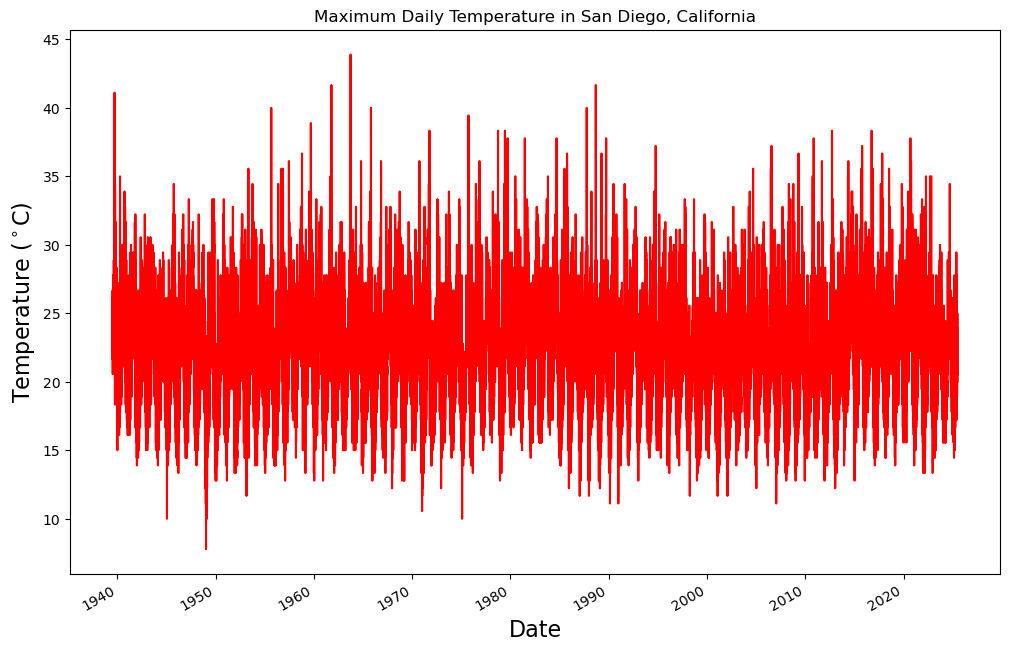

In [8]:
### plot cleaned data
sd_max_daily_temp_plot = sd_max_temp_units_df.plot(
    y = 'temp_c',
    title = 'Maximum Daily Temperature in San Diego, California',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize = (12,8),
    color = 'red'
)

### increase axis label size
sd_max_daily_temp_plot.set_xlabel('Date', fontsize=16)
sd_max_daily_temp_plot.set_ylabel('Temperature ($^\circ$C)', fontsize=16)

### increase title size
sd_max_daily_temp_plot.set_title('Maximum Daily Temperature in San Diego,' \
' California')

### remove legend
sd_max_daily_temp_plot.legend().remove()



In [9]:
### resample to get annual mean
sd_ann_max_temp_df = (

### resample dataframe
    sd_max_temp_units_df

    ### sample yearly
    .resample('YE')

    ### calculate mean
    .mean()
)

sd_ann_max_temp_df

,temp_f,temp_c
DATE,,
1939-12-31,75.581522,24.211957
1940-12-31,71.245902,21.803279
1941-12-31,72.167123,22.315068
1942-12-31,70.931507,21.628615
1943-12-31,71.879452,22.155251
...,...,...
2021-12-31,71.520548,21.955860
2022-12-31,71.219178,21.788432
2023-12-31,69.816438,21.009132


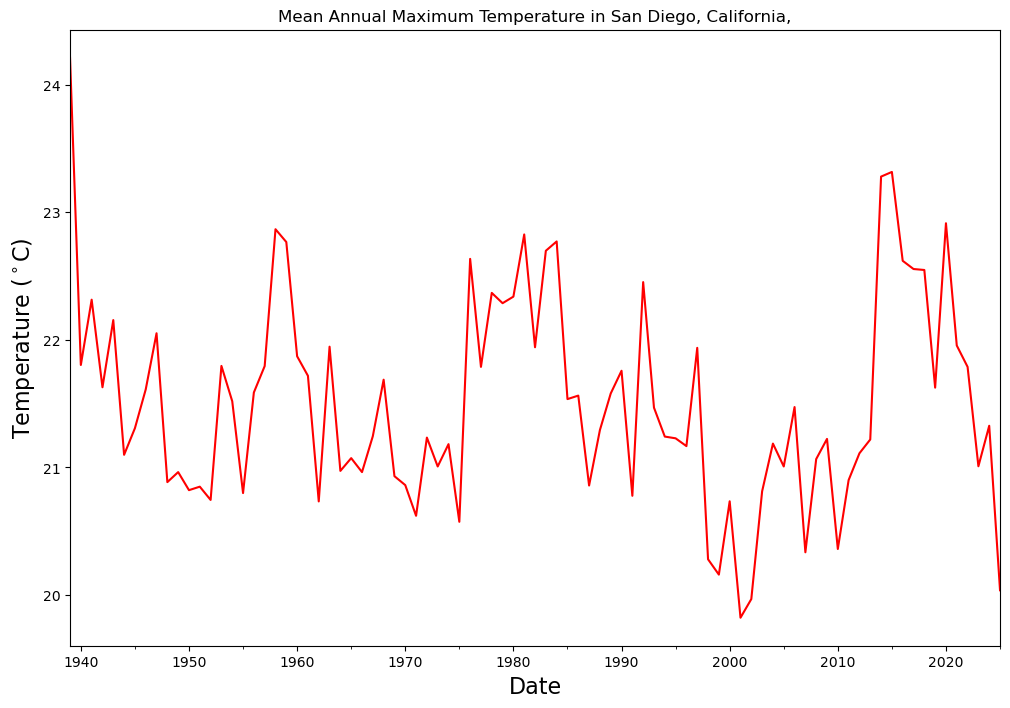

In [10]:
### plot annual meandata
sd_ann_max_temp_plot = sd_ann_max_temp_df.plot(
    y = 'temp_c',
    title = 'Mean Annual Maximum Temperature in San Diego, California',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize = (12,8),
    color = 'red'
)

### increase axis label size
sd_ann_max_temp_plot.set_xlabel('Date', fontsize=16)
sd_ann_max_temp_plot.set_ylabel('Temperature ($^\circ$C)', fontsize=16)

### increase title size
sd_ann_max_temp_plot.set_title('Mean Annual Maximum Temperature in ' \
'San Diego, California,' \
)

### remove legend
sd_ann_max_temp_plot.legend().remove()



In [11]:
### generate an interactive plot of data
sd_ann_max_temp_hvplot = sd_ann_max_temp_df.hvplot(
    y = 'temp_c',
            title = 'Mean Maximum Annual Temperature in Boulder, Colorado',
            xlabel = 'Year',
            ylabel = 'Temperature (Celsius)',
            color = 'green',
            fontsize = 14
    )
### save hvplot
hvplot.save(sd_ann_max_temp_hvplot, 'sd_ann_max_temp_hvplot.html', resources = 'inline')

sd_ann_max_temp_hvplot

:Curve   [DATE]   (temp_c)

In [12]:

### subset data to focus on celsius
sd_ann_max_temp_c_df = sd_ann_max_temp_df[['temp_c']]

sd_ann_max_temp_c_df

,temp_c
DATE,
1939-12-31,24.211957
1940-12-31,21.803279
1941-12-31,22.315068
1942-12-31,21.628615
1943-12-31,22.155251
...,...
2021-12-31,21.955860
2022-12-31,21.788432
2023-12-31,21.009132


In [17]:
### fit an ols regression line to data

### define ind variable
### reshape year to be a 2d array for scikit-learn
ind_variable = sd_ann_max_temp_c_df.index.year.values.reshape(-1,1)

### define dep variable
dep_variable = sd_ann_max_temp_c_df

### generate linear regression mdoel
model = LinearRegression()

### fit model to data
model.fit(ind_variable, dep_variable)

### calculate r squared
r_squared = model.score(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')
print(f'R-squared: {r_squared}')

Slope: [-0.00275005] degrees per year
R-squared: 0.007056778569834443


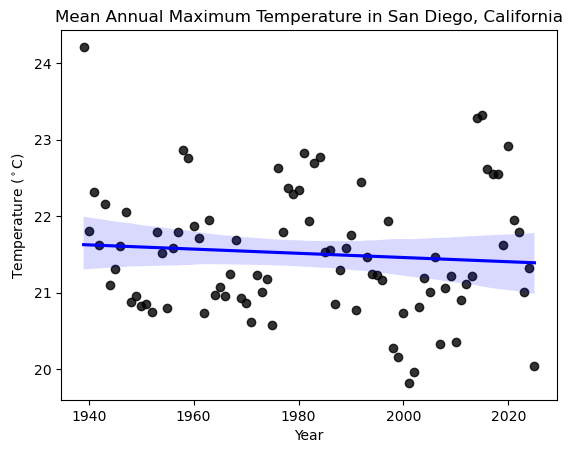

In [14]:
### generate plot with a trend line fir to the data
ax = sns.regplot(
    x = sd_ann_max_temp_c_df.index.year,
    y = sd_ann_max_temp_c_df,

    ### change color of data points
    color = 'black',

    ### change color of trend line
    line_kws = {'color' : 'blue'}
)

### label plot
ax.set(
    title = 'Mean Annual Maximum Temperature in San Diego, California',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save plot
plt.savefig('/workspaces/01-climate-change-coding-project/sandiego_max_' \
'annual_temp.jpeg')

### display plot
plt.show()